# Titanic: Binary Classification

**Business question:** Can we predict which passengers survived the Titanic disaster, using demographic and ticketing data? A model that answers this demonstrates the full binary classification workflow: EDA, preprocessing, model selection, and evaluation beyond accuracy.

**Models compared:** Logistic Regression · Random Forest · K-Nearest Neighbours

**Evaluation:** Confusion matrix · Precision · Recall · F1 · ROC-AUC

## Section 1: Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

# --- constants ---
RANDOM_STATE = 42
TEST_SIZE    = 0.2
DATA_PATH    = '../data/train.csv'

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print(f"Using random state: {RANDOM_STATE}")
print(f"Test size: {TEST_SIZE}")
print(f"Data path: {DATA_PATH}")

Using random state: 42
Test size: 0.2
Data path: ../data/train.csv


## Section 2: Data Loading and First Look

In [2]:
# Load the dataset
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")

Loaded 891 rows, 12 columns


In [3]:
# Describing the dataset
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nDescriptive Stats:")
display(df.describe())
missing = df.isnull().sum()
print("\nMissing Values:")
display(missing[missing > 0].sort_values(ascending=False))

Shape: (891, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Descriptive Stats:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values:


Cabin       687
Age         177
Embarked      2
dtype: int64

In [4]:
# Class balance
counts = df['Survived'].value_counts()
rate = df['Survived'].mean() * 100
print(f"Survived:         {counts[1]} ({rate:.1f}%)")
print(f"Did not survive:  {counts[0]} ({100 - rate:.1f}%)")

Survived:         342 (38.4%)
Did not survive:  549 (61.6%)


### Observations:
- 891 rows, 12 columns. Survived is the target, binary, no nulls.
- Dataset is imbalanced: 62% did not survive. A model that always predicts "dead" scores 61.6% accuracy without learning anything. This is why we use precision, recall, and AUC.
- Three missing value problems at very different scales. Cabin is 77% missing so we drop it. Age is 20% missing so we impute with the median. Embarked has just 2 missing rows so we impute with the mode.
- Fare is right-skewed. Median is £14, mean is £32, max is £512. A handful of very expensive tickets pull the average up significantly.
- Most passengers travelled alone. Median SibSp and Parch are both 0.

## Section 3: Exploratory Data Analysis

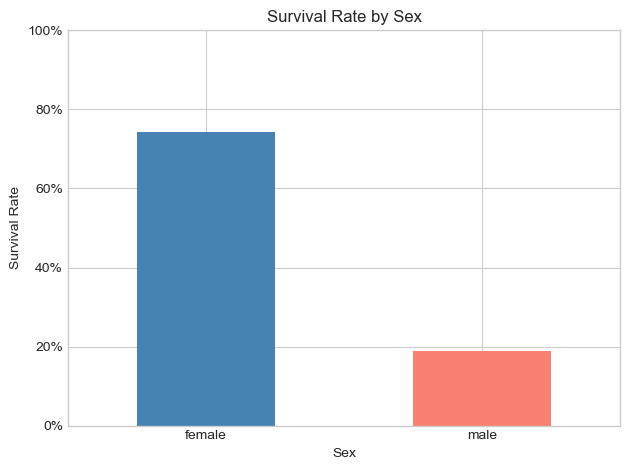

In [5]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()

fig, ax = plt.subplots()
survival_by_sex.plot.bar(ax=ax, color=['steelblue', 'salmon'])
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Sex')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/survival_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()

### Observation:
Women survived at ~75%, men at ~19%. A 56 percentage point gap. Sex is the strongest predictor in this dataset. Get this feature right and the model is already most of the way there.

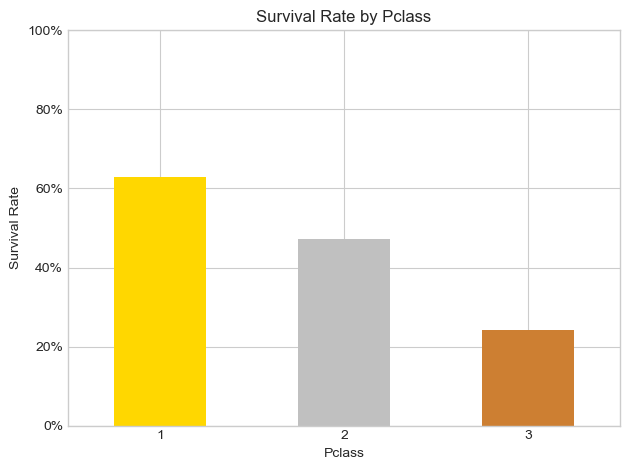

In [6]:
survival_by_pclass = df.groupby('Pclass')['Survived'].mean()

fig, ax = plt.subplots()
survival_by_pclass.plot.bar(ax=ax, color=['gold', 'silver', '#cd7f32'])
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Pclass')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/survival_by_pclass.png', dpi=150, bbox_inches='tight')
plt.show()

### Observation:
First class survived at ~63%, second at ~48%, third at ~25%. The drop from second to third is steeper than from first to second. Pclass wasn't just wealth. It determined where you were on the ship and how quickly you could reach a lifeboat.

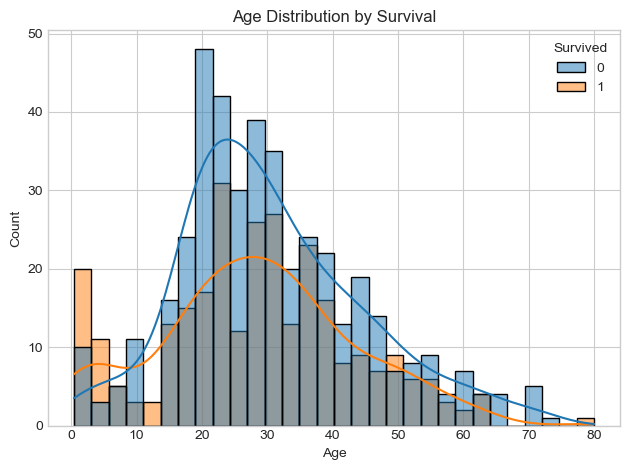

In [7]:
fig, ax = plt.subplots()
sns.histplot(data=df, x='Age', hue='Survived', kde=True, ax=ax, bins=30)
ax.set_title('Age Distribution by Survival')
ax.set_xlabel('Age')
plt.tight_layout()
plt.savefig('../images/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Observation:
The two distributions overlap heavily across almost the entire age range, so Age alone is a weak predictor. The clearest signal is under 10. Survivors outnumber non-survivors in that bin, consistent with children being prioritised during evacuation. Beyond that, the KDE curves track each other closely.

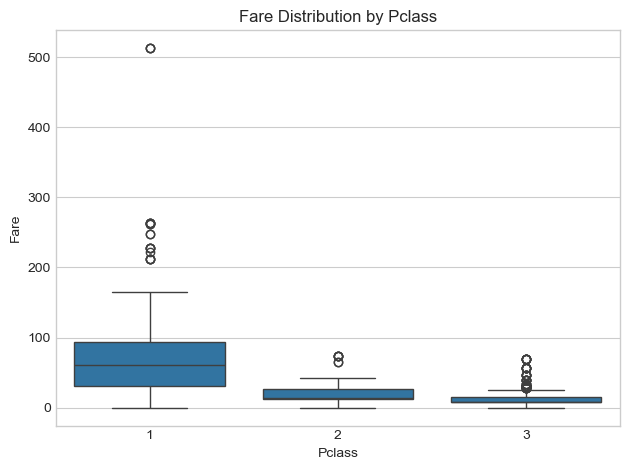

In [8]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Pclass', y='Fare', ax=ax)
ax.set_title('Fare Distribution by Pclass')
plt.tight_layout()
plt.savefig('../images/fare_by_pclass.png', dpi=150, bbox_inches='tight')
plt.show()

### Observation:
First class fares span roughly £0 to £170 for most passengers, with outliers above £200 and one above £500. Second and third class boxes sit compressed near the bottom. This matches what Section 2 already told us: median fare is £14 but the mean is £32, pulled up by first class outliers.

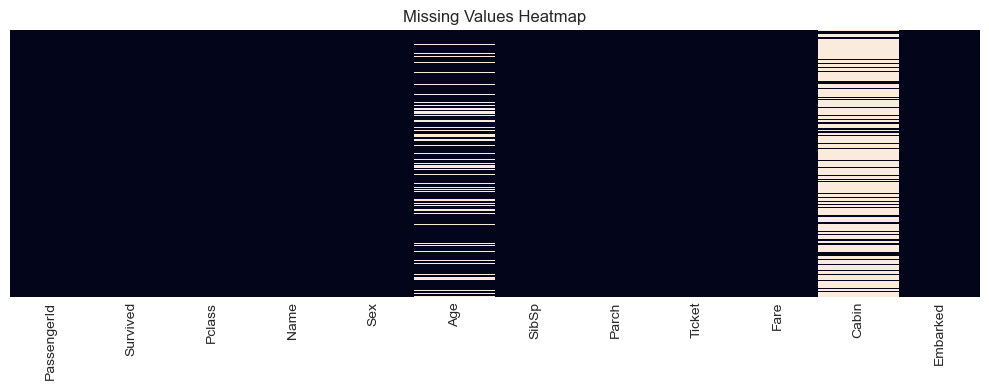

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, ax=ax)
ax.set_title('Missing Values Heatmap')
plt.tight_layout()
plt.savefig('../images/missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### Observation:
Age gaps are scattered with no obvious row clustering, which supports random missingness and justifies median imputation. Cabin is almost entirely light. The dark stripes are the 23% of rows that actually have a cabin value. Embarked's two missing rows are invisible at this scale.

## Section 4: Preprocessing

**Decisions documented here:**

| Column | Action | Reason |
|---|---|---|
| PassengerId | Drop | Row identifier, no signal |
| Name | Drop | Free text, not encoded this session |
| Ticket | Drop | High-cardinality, no clear signal |
| Cabin | Drop | >75% missing. Imputation would be noise |
| Age | Impute (median) | ~20% missing; median robust to skew |
| Embarked | Impute (mode) | 2 rows missing; mode is safe |
| Sex | Binary encode (0/1) | Nominal, two categories |
| Embarked | One-hot encode | Nominal, three categories |

**Scaling strategy:** Logistic Regression and KNN receive scaled features (StandardScaler fit on train only). Random Forest receives the same encoded features unscaled. Tree splits are scale-invariant, so scaling adds nothing and would obscure the deliberate comparison.

In [10]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)

y = df['Survived']
X = df.drop(columns=['Survived'])

print(X.shape)
print(X.head())

(891, 8)
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0       3    0  22.0      1      0   7.2500           0           1
1       1    1  38.0      1      0  71.2833           0           0
2       3    1  26.0      0      0   7.9250           0           1
3       1    1  35.0      1      0  53.1000           0           1
4       3    0  35.0      0      0   8.0500           0           1


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))

(712, 8) (179, 8)
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64


## Section 5: Baseline (DummyClassifier)

Before any real model, establish a floor. A DummyClassifier predicting the majority class every time sets the minimum bar. Any model that can't beat this is useless.

In [26]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

print('Dummy accuracy:', accuracy_score(y_test, dummy_preds))
print(classification_report(y_test, dummy_preds, zero_division=0))

Dummy accuracy: 0.6145251396648045
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179



## Section 6: Model 1 - Logistic Regression

Logistic Regression is the natural first real model for binary classification. It's interpretable (coefficients map to log-odds), trains fast, and gives well-calibrated probabilities. Requires scaled features.

In [21]:
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

print(classification_report(y_test, lr_preds))

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
print(coef_df)

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

      feature  coefficient  odds_ratio
1         Sex     1.269598    3.559422
0      Pclass    -0.928698    0.395068
2         Age    -0.502878    0.604788
3       SibSp    -0.262672    0.768994
7  Embarked_S    -0.171784    0.842161
5        Fare     0.099599    1.104728
6  Embarked_Q     0.080683    1.084027
4       Parch    -0.067158    0.935048


### Observations:
80% accuracy against a 61% dummy baseline. Sex has the largest coefficient. An odds ratio of 3.56 means being female multiplied survival odds by 3.5x. Pclass is second, negative as expected. Age is also negative. Fare and Embarked contribute almost nothing.

## Section 7: Model 2 - Random Forest

Random Forest is an ensemble of decision trees trained via bagging. No scaling needed. Splits are threshold-based on one feature at a time. OOB score gives a free out-of-sample estimate without touching the test set.

In [22]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, oob_score=True)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print('OOB Score:', rf.oob_score_)
print(classification_report(y_test, rf_preds))

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)

OOB Score: 0.8047752808988764
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179

      feature  importance
5        Fare    0.276370
1         Sex    0.260508
2         Age    0.252607
0      Pclass    0.085310
3       SibSp    0.049594
4       Parch    0.040142
7  Embarked_S    0.025229
6  Embarked_Q    0.010240


### Observations:
81% accuracy. OOB score of 80.5% is close to test accuracy, so the model isn't overfitting. Feature importance is more spread out than LR's coefficients. Fare, Sex, and Age are nearly equal at the top, with Pclass dropping to fourth. LR put Sex clearly ahead of everything else. RF picks up non-linear relationships, so a flatter importance spread makes sense.

## Section 8: Model 3 - K-Nearest Neighbours

KNN makes no assumptions about decision boundary shape. It classifies by majority vote among the k nearest training points. Distance-based, so scaling is mandatory. We sweep k to find the best value before fitting the final model.

In [23]:
k_values = [1, 3, 5, 7, 10, 15, 20, 25]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = k_values[int(np.argmax(accuracies))]
print(f'Best k: {best_k}')
print(list(zip(k_values, [round(a, 3) for a in accuracies])))

Best k: 7
[(1, 0.793), (3, 0.81), (5, 0.816), (7, 0.821), (10, 0.799), (15, 0.821), (20, 0.816), (25, 0.81)]


In [24]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)

print(classification_report(y_test, knn_preds))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



### Observations:
Best k is 7. Accuracy rises from 79.3% at k=1 to 82.1% at k=7, drops at k=10, then recovers at k=15 before falling again. Small k overfits to noise, large k smooths too much. k=7 gives 82.1%, the highest accuracy of the three models. Recall on survivors is 74%, slightly ahead of LR and RF.

## Section 9: Model Comparison

All three ROC curves on one axes, plus a summary table. The goal is not just to find the best number. It is to explain what each metric means in this context.

**Framing the trade-off:** A false negative here means predicting a passenger *survived* when they actually *died*. A false positive means predicting *death* when they survived. For a historical analysis, neither error carries real stakes. In a real-world analogy (e.g. identifying high-risk patients) false negatives are typically more costly. Recall is the metric sensitive to false negatives.

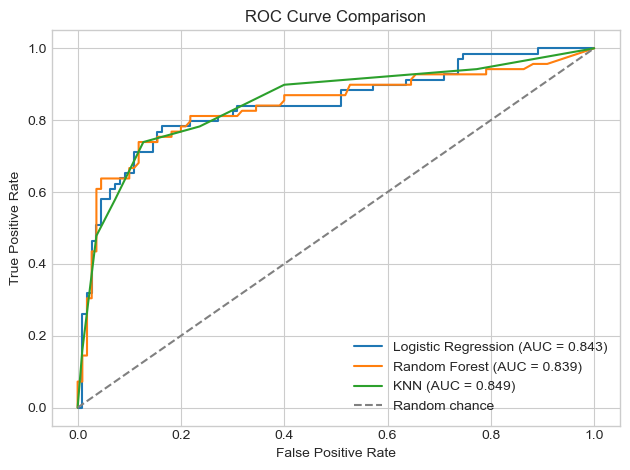

In [27]:
fig, ax = plt.subplots()

for model, X_t, label in [
    (lr,  X_test_scaled, 'Logistic Regression'),
    (rf,  X_test,        'Random Forest'),
    (knn, X_test_scaled, 'KNN'),
]:
    y_proba = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], '--', color='grey', label='Random chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('../images/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
results = []
for name, model, X_t in [
    ('Logistic Regression', lr,  X_test_scaled),
    ('Random Forest',       rf,  X_test),
    ('KNN',                 knn, X_test_scaled),
]:
    preds = model.predict(X_t)
    proba = model.predict_proba(X_t)[:, 1]
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, preds), 3),
        'Precision': round(report['1']['precision'], 3),
        'Recall':    round(report['1']['recall'], 3),
        'F1':        round(report['1']['f1-score'], 3),
        'AUC':       round(roc_auc_score(y_test, proba), 3),
    })

print(pd.DataFrame(results).to_string(index=False))

              Model  Accuracy  Precision  Recall    F1   AUC
Logistic Regression     0.804      0.793   0.667 0.724 0.843
      Random Forest     0.810      0.787   0.696 0.738 0.839
                KNN     0.821      0.785   0.739 0.761 0.849


### Interpretation:
The three models are close across every metric. No single winner on all fronts. KNN has the highest accuracy (82.1%) and AUC (0.849), and the best recall on survivors (73.9%). LR has the highest precision (79.3%) but the lowest recall (66.7%), meaning it is the most conservative about predicting survival and misses more survivors as a result. RF sits between the two on most metrics.

The ROC curves confirm this. All three track closely, pulling well clear of random chance from the start. KNN and LR are nearly identical in the early part of the curve where the model is most confident. RF trails slightly in the middle range.

If the goal were to minimise false negatives (missing survivors), KNN is the pick. If precision matters more, LR. For a historical analysis with no real operational stakes, the differences are small enough that model choice comes down to what you need from it: interpretability favours LR, raw performance favours KNN.

## Section 10: Conclusions

**What worked:**

All three models beat the 61.4% dummy baseline by a meaningful margin. The preprocessing decisions held up: algorithm-appropriate scaling, median imputation for Age, and dropping Cabin rather than imputing a column that is 77% missing. Stratified splitting kept class proportions intact across train and test sets.

Logistic Regression was the most informative model. The coefficient table confirmed what the EDA showed: Sex was the dominant predictor by a large margin, with an odds ratio of 3.56 for female passengers. Pclass and Age followed. Fare and Embarked contributed almost nothing, which is consistent with their low correlation to survival once class is already encoded.

Random Forest's OOB score of 80.5% matched test accuracy closely, confirming the model generalised well without overfitting. Its feature importance spread was flatter than LR's coefficients, with Fare, Sex, and Age nearly equal. This reflects RF's ability to capture non-linear interactions that LR misses.

KNN at k=7 was the strongest performer on accuracy (82.1%) and recall on survivors (73.9%). The k sweep showed a clear optimum before accuracy degraded in both directions.

**Limitations:**

A single train/test split is sensitive to which rows end up in each set. Cross-validation would give a more stable estimate. Hyperparameters were not tuned beyond the k sweep for KNN. Random Forest used default settings for n_estimators and max_depth.

**What I'd try next:**
- Feature engineering: family size (SibSp + Parch + 1), title extraction from Name, deck from Cabin prefix
- sklearn Pipeline wrapping preprocessing and model together
- Cross-validation instead of a single train/test split
- Hyperparameter tuning with GridSearchCV
- XGBoost comparison